In [ ]:
# import graphlab
# products = graphlab.SFrame('amazon_baby.gl/')

In [2]:
import pandas as pd

products = pd.read_csv('amazon_baby.csv')

# 中身確認（SFrameと同様の操作）
display(products.head())
display(products.shape)
display(products.dtypes)

,name,review,rating
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5


(183531, 3)

name      object
review    object
rating     int64
dtype: object

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

In [5]:
# Build word count vector
# products['word_count'] = graphlab.text_analytics.count_words(products['review'])

# シンプルにCounterで辞書形式にする（GraphLabと同じ出力形式）
def count_words(text):
    if isinstance(text, str):
        words = re.findall(r'\b\w+\b', text.lower())
        return dict(Counter(words))
    return {}

products['word_count'] = products['review'].apply(count_words)
display(products)

,name,review,rating,word_count
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3,"{'these': 1, 'flannel': 1, 'wipes': 4, 'are': ..."
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,"{'it': 3, 'came': 1, 'early': 1, 'and': 3, 'wa..."
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,"{'very': 1, 'soft': 1, 'and': 2, 'comfortable'..."
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,"{'this': 4, 'is': 4, 'a': 2, 'product': 2, 'we..."
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,"{'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'..."
...,...,...,...,...
183526,Baby Teething Necklace for Mom Pretty Donut Sh...,Such a great idea! very handy to have and look...,5,"{'such': 1, 'a': 1, 'great': 2, 'idea': 1, 've..."
183527,Baby Teething Necklace for Mom Pretty Donut Sh...,This product rocks! It is a great blend of fu...,5,"{'this': 1, 'product': 2, 'rocks': 1, 'it': 2,..."
183528,Abstract 2 PK Baby / Toddler Training Cup (Pink),This item looks great and cool for my kids.......,5,"{'this': 2, 'item': 1, 'looks': 1, 'great': 2,..."
183529,"Baby Food Freezer Tray - Bacteria Resistant, B...",I am extremely happy with this product. I have...,5,"{'i': 9, 'am': 2, 'extremely': 1, 'happy': 1, ..."


In [ ]:
# graphlab.canvas.set_target('ipynb')

# products['name'].show()

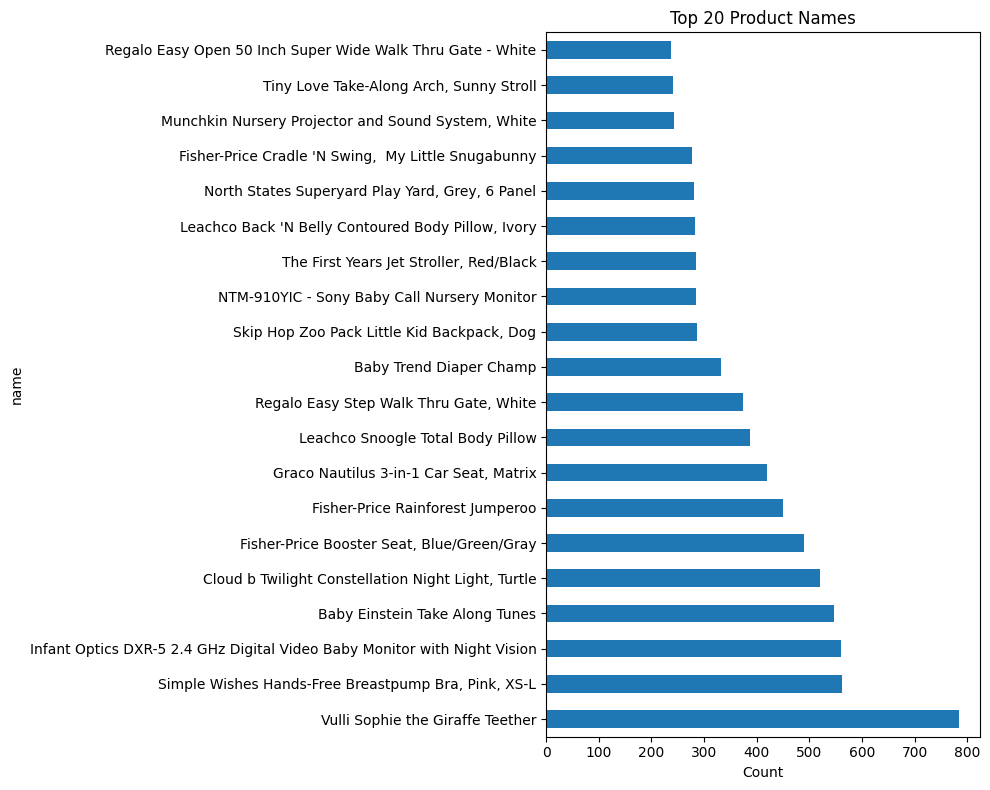

In [6]:
import matplotlib.pyplot as plt

# 商品名の出現頻度トップ20を棒グラフで表示
products['name'].value_counts().head(20).plot(kind='barh', figsize=(10, 8))
plt.title('Top 20 Product Names')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

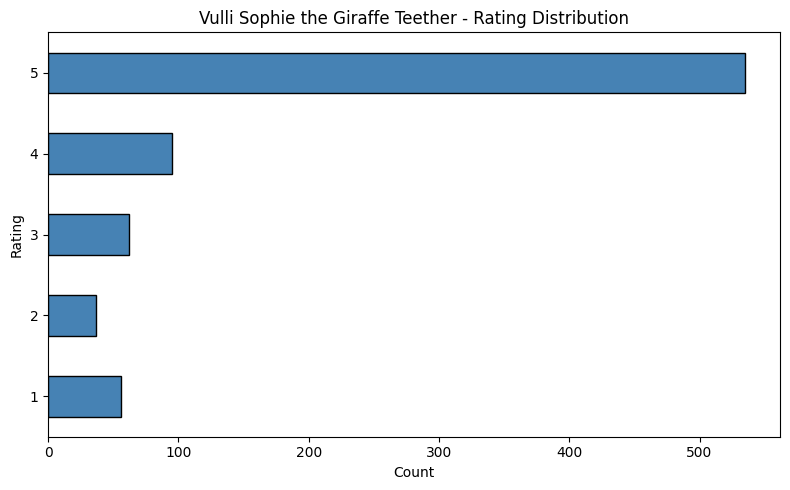

In [9]:
# 'Vulli Sophie the Giraffe Teether'（キリンのソフィー歯固め）の
# # レビューだけを抽出してフィルタリング
# giraffe_reviews = products[products['name'] == 'Vulli Sophie the Giraffe Teether']

# # 該当商品のレビュー件数を確認 → 785件
# len(giraffe_reviews)

# # rating列をカテゴリカル（棒グラフ）として可視化するGraphLab独自の機能
# # 1〜5の各評価が何件あるかを表示
# giraffe_reviews['rating'].show(view='Categorical')

giraffe_reviews = products[products['name'] == 'Vulli Sophie the Giraffe Teether']

len(giraffe_reviews)

# value_counts()で各評価の件数を集計し棒グラフで表示
import matplotlib.pyplot as plt
giraffe_reviews['rating'].value_counts().sort_index(ascending=True).plot(
    kind='barh',  # 横向き棒グラフ
    figsize=(8, 5),
    color='steelblue',
    edgecolor='black'
)
plt.title('Vulli Sophie the Giraffe Teether - Rating Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

In [ ]:
# BUILD SENTIMENT CLASSIFIER


In [11]:
# # ポジティブな感情 = 評価4以上（4★または5★）を1(True)、それ以外を0(False)として
# # sentiment列を新たに作成
# products['sentiment'] = products['rating'] >= 4

# pandasでも全く同じ書き方でOK
products['sentiment'] = products['rating'] >= 4
display(products)

,name,review,rating,word_count,sentiment
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3,"{'these': 1, 'flannel': 1, 'wipes': 4, 'are': ...",False
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,"{'it': 3, 'came': 1, 'early': 1, 'and': 3, 'wa...",True
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,"{'very': 1, 'soft': 1, 'and': 2, 'comfortable'...",True
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,"{'this': 4, 'is': 4, 'a': 2, 'product': 2, 'we...",True
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,"{'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'...",True
...,...,...,...,...,...
183526,Baby Teething Necklace for Mom Pretty Donut Sh...,Such a great idea! very handy to have and look...,5,"{'such': 1, 'a': 1, 'great': 2, 'idea': 1, 've...",True
183527,Baby Teething Necklace for Mom Pretty Donut Sh...,This product rocks! It is a great blend of fu...,5,"{'this': 1, 'product': 2, 'rocks': 1, 'it': 2,...",True
183528,Abstract 2 PK Baby / Toddler Training Cup (Pink),This item looks great and cool for my kids.......,5,"{'this': 2, 'item': 1, 'looks': 1, 'great': 2,...",True
183529,"Baby Food Freezer Tray - Bacteria Resistant, B...",I am extremely happy with this product. I have...,5,"{'i': 9, 'am': 2, 'extremely': 1, 'happy': 1, ...",True


In [12]:
# # データを80%训練用、20%テスト用にランダム分割（seed=0で再現性を確保）
# train_data, test_data = products.random_split(.8, seed=0)

# # ロジスティック回帰で感情分類モデルを学習
# # target: 予測したい列（sentiment）
# # features: 入力に使う列（word_count）
# # validation_set: 学習中の精度確認用にテストデータを使用
# sentiment_model = graphlab.logistic_classifier.create(train_data,
#                                                       target='sentiment',
#                                                       features=['word_count'],
#                                                       validation_set=test_data)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score

train_data, test_data = train_test_split(products, test_size=0.2, random_state=0)

y_train = train_data['sentiment']
y_test = test_data['sentiment']

# --- 方法1: word_count（以前作った辞書）を使う ---
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer()
X_train_wc = dv.fit_transform(train_data['word_count'])
X_test_wc = dv.transform(test_data['word_count'])

model_wc = LogisticRegression(max_iter=1000)
model_wc.fit(X_train_wc, y_train)
acc_wc = accuracy_score(y_test, model_wc.predict(X_test_wc))

# --- 方法2: CountVectorizerを使う ---
cv = CountVectorizer()
X_train_cv = cv.fit_transform(train_data['review'].fillna(''))
X_test_cv = cv.transform(test_data['review'].fillna(''))

model_cv = LogisticRegression(max_iter=1000)
model_cv.fit(X_train_cv, y_train)
acc_cv = accuracy_score(y_test, model_cv.predict(X_test_cv))

# --- 結果比較 ---
print(f"word_count精度:       {acc_wc:.4f}")
print(f"CountVectorizer精度:  {acc_cv:.4f}")

/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/pytho

word_count精度:       0.8837
CountVectorizer精度:  0.8831


/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20605 (\N{CJK UNIFIED IDEOGRAPH-507D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38525 (\N{CJK UNIFIED IDEOGRAPH-967D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/I

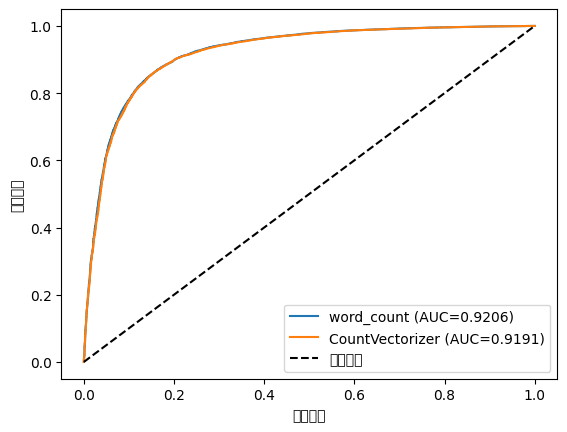

In [14]:
# # モデルの評価結果（精度・ROC曲線など）をインタラクティブに可視化する
# # GraphLab独自の機能
# sentiment_model.show(view='Evaluation')

# # モデルの性能をROC曲線で評価する
# # ROC曲線：偽陽性率と真陽性率のトレードオフを視覚化したもの
# sentiment_model.evaluate(test_data, metric='roc_curve')

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 各モデルの予測確率を取得
y_prob_wc = model_wc.predict_proba(X_test_wc)[:, 1]
y_prob_cv = model_cv.predict_proba(X_test_cv)[:, 1]

# ROC曲線の計算と表示
fpr_wc, tpr_wc, _ = roc_curve(y_test, y_prob_wc)
fpr_cv, tpr_cv, _ = roc_curve(y_test, y_prob_cv)

plt.plot(fpr_wc, tpr_wc, label=f'word_count (AUC={roc_auc_score(y_test, y_prob_wc):.4f})')
plt.plot(fpr_cv, tpr_cv, label=f'CountVectorizer (AUC={roc_auc_score(y_test, y_prob_cv):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='ランダム')
plt.xlabel('偽陽性率')
plt.ylabel('真陽性率')
plt.legend()
plt.show()


In [15]:
# # giraffe_reviewsの各レビューに対して、ポジティブである確率を予測し
# # predicted_sentiment列として追加する
# giraffe_reviews['predicted_sentiment'] = sentiment_model.predict(giraffe_reviews, output_type='probability')

# DictVectorizerでgiraffe_reviewsのword_countをベクトル化
X_giraffe = dv.transform(giraffe_reviews['word_count'])

# ポジティブ（True）である確率を取得（[:, 1]で肯定クラスの確率を抽出）
giraffe_reviews['predicted_sentiment'] = model_wc.predict_proba(X_giraffe)[:, 1]


/var/folders/2m/7h2jrr2d1t7g21gj_sxr5n2h0000gn/T/ipykernel_94365/1939977165.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  giraffe_reviews['predicted_sentiment'] = model_wc.predict_proba(X_giraffe)[:, 1]


In [16]:
display(giraffe_reviews)

,name,review,rating,word_count,predicted_sentiment
34313,Vulli Sophie the Giraffe Teether,He likes chewing on all the parts especially t...,5,"{'he': 2, 'likes': 1, 'chewing': 1, 'on': 1, '...",0.983448
34314,Vulli Sophie the Giraffe Teether,My son loves this toy and fits great in the di...,5,"{'my': 1, 'son': 1, 'loves': 1, 'this': 1, 'to...",0.995480
34315,Vulli Sophie the Giraffe Teether,There really should be a large warning on the ...,1,"{'there': 2, 'really': 1, 'should': 1, 'be': 1...",0.258102
34316,Vulli Sophie the Giraffe Teether,All the moms in my moms' group got Sophie for ...,5,"{'all': 1, 'the': 2, 'moms': 2, 'in': 1, 'my':...",0.957695
34317,Vulli Sophie the Giraffe Teether,I was a little skeptical on whether Sophie was...,5,"{'i': 4, 'was': 2, 'a': 1, 'little': 1, 'skept...",0.739987
...,...,...,...,...,...
159649,Vulli Sophie the Giraffe Teether,My baby loves her Sophie Chew Toy. She can che...,5,"{'my': 2, 'baby': 1, 'loves': 1, 'her': 1, 'so...",0.972200
159650,Vulli Sophie the Giraffe Teether,Sophie the Giraffe was a big hit at the baby s...,5,"{'sophie': 2, 'the': 2, 'giraffe': 1, 'was': 1...",0.878132
159651,Vulli Sophie the Giraffe Teether,quick shipping and perfect product. I would pu...,5,"{'quick': 1, 'shipping': 1, 'and': 1, 'perfect...",0.997911
159652,Vulli Sophie the Giraffe Teether,My baby who is currently teething love his Sop...,5,"{'my': 1, 'baby': 1, 'who': 1, 'is': 1, 'curre...",0.923910


In [17]:
pd.set_option('display.max_colwidth', None)  # 列の文字数制限を解除

# スクロール可能な形式で表示
from IPython.display import HTML

HTML(giraffe_reviews.to_html())


,name,review,rating,word_count,predicted_sentiment
34313,Vulli Sophie the Giraffe Teether,He likes chewing on all the parts especially the head and the ears! It has helped when he has been cranky because of teething. Great purchase!,5,"{'he': 2, 'likes': 1, 'chewing': 1, 'on': 1, 'all': 1, 'the': 3, 'parts': 1, 'especially': 1, 'head': 1, 'and': 1, 'ears': 1, 'it': 1, 'has': 2, 'helped': 1, 'when': 1, 'been': 1, 'cranky': 1, 'because': 1, 'of': 1, 'teething': 1, 'great': 1, 'purchase': 1}",0.983448
34314,Vulli Sophie the Giraffe Teether,"My son loves this toy and fits great in the diaper bag. Also very easy to clean, just run right under the water. Seems to help him when he is getting a tooth.",5,"{'my': 1, 'son': 1, 'loves': 1, 'this': 1, 'toy': 1, 'and': 1, 'fits': 1, 'great': 1, 'in': 1, 'the': 2, 'diaper': 1, 'bag': 1, 'also': 1, 'very': 1, 'easy': 1, 'to': 2, 'clean': 1, 'just': 1, 'run': 1, 'right': 1, 'under': 1, 'water': 1, 'seems': 1, 'help': 1, 'him': 1, 'when': 1, 'he': 1, 'is': 1, 'getting': 1, 'a': 1, 'tooth': 1}",0.995480
34315,Vulli Sophie the Giraffe Teether,"There really should be a large warning on the box. Sheesh, in 2011 with so many anaphylactic latex allergies and Latex being an allergy that is caused by repeated exposure why in the world would someone think an all latex teether was a good idea for a baby?? This baby teether could have quite easily killed mommy and there was no warning on the packaging that is made of latex.",1,"{'there': 2, 'really': 1, 'should': 1, 'be': 1, 'a': 3, 'large': 1, 'warning': 2, 'on': 2, 'the': 3, 'box': 1, 'sheesh': 1, 'in': 2, '2011': 1, 'with': 1, 'so': 1, 'many': 1, 'anaphylactic': 1, 'latex': 4, 'allergies': 1, 'and': 2, 'being': 1, 'an': 2, 'allergy': 1, 'that': 2, 'is': 2, 'caused': 1, 'by': 1, 'repeated': 1, 'exposure': 1, 'why': 1, 'world': 1, 'would': 1, 'someone': 1, 'think': 1, 'all': 1, 'teether': 2, 'was': 2, 'good': 1, 'idea': 1, 'for': 1, 'baby': 2, 'this': 1, 'could': 1, 'have': 1, 'quite': 1, 'easily': 1, 'killed': 1, 'mommy': 1, 'no': 1, 'packaging': 1, 'made': 1, 'of': 1}",0.258102
34316,Vulli Sophie the Giraffe Teether,"All the moms in my moms' group got Sophie for their babies so I wondered if there was something to the hype and got one too. My daughter LOVES Sophie. Kids really do love this thing. If we, heaven forbid, ever lost Sophie I'd have to run out and buy another one!",5,"{'all': 1, 'the': 2, 'moms': 2, 'in': 1, 'my': 2, 'group': 1, 'got': 2, 'sophie': 3, 'for': 1, 'their': 1, 'babies': 1, 'so': 1, 'i': 2, 'wondered': 1, 'if': 2, 'there': 1, 'was': 1, 'something': 1, 'to': 2, 'hype': 1, 'and': 2, 'one': 2, 'too': 1, 'daughter': 1, 'loves': 1, 'kids': 1, 'really': 1, 'do': 1, 'love': 1, 'this': 1, 'thing': 1, 'we': 1, 'heaven': 1, 'forbid': 1, 'ever': 1, 'lost': 1, 'd': 1, 'have': 1, 'run': 1, 'out': 1, 'buy': 1, 'another': 1}",0.957695
34317,Vulli Sophie the Giraffe Teether,"I was a little skeptical on whether Sophie was going to be worth the money, but after it arrived today I am very happy that I bought her. My is almost 6 months old and is getting his two bottom teeth and he has not put her down all day. He even carried her in his hands for 20 minutes while I shopped with him in the Bjorn. Everything about this toy is wonderful. Even the Squeak is not like some of those annoying squeaker toys out there. If you are thinking about rather or not to buy Sophie take it from me and buy her you will not be disappointed!",5,"{'i': 4, 'was': 2, 'a': 1, 'little': 1, 'skeptical': 1, 'on': 1, 'whether': 1, 'sophie': 2, 'going': 1, 'to': 2, 'be': 2, 'worth': 1, 'the': 3, 'money': 1, 'but': 1, 'after': 1, 'it': 2, 'arrived': 1, 'today': 1, 'am': 1, 'very': 1, 'happy': 1, 'that': 1, 'bought': 1, 'her': 4, 'my': 1, 'is': 4, 'almost': 1, '6': 1, 'months': 1, 'old': 1, 'and': 3, 'getting': 1, 'his': 2, 'two': 1, 'bottom': 1, 'teeth': 1, 'he': 2, 'has': 1, 'not': 4, 'put': 1, 'down': 1, 'all': 1, 'day': 1, 'even': 2, 'carried': 1, 'in': 2, 'hands': 1, 'for': 1